In [3]:
import geopandas as geo
import pandas as pd
import xarray as xr
from shapely.geometry import Point
import matplotlib.pyplot as plt
from pystac_client import Client
import odc.stac

In [2]:
df = geo.read_file("../export/estaciones.geojson")

In [3]:
df.head()

,nombre,type,id,geometry
0,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892)
1,Mercedes G3,METEO,e1f1c3a0-5d86-8d95-c20c-01d11eecd94d,POINT (-58.0305 -33.2524)
2,Artigas G3,METEO,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,POINT (-56.4667 -30.4)
3,Rocha G3,METEO,fca40b66-3095-bb02-f981-15365abf3389,POINT (-54.3333 -34.4833)
4,Colonia G3,METEO,1bf028c9-b910-8138-0f6d-e56ad8261159,POINT (-57.8398 -34.4626)


In [4]:
df["type"].unique()

<StringArray>
['METEO', 'CLIMA', 'GEMS']
Length: 3, dtype: str

In [5]:
mask = df["type"]  == "GEMS" 
pd.set_option("display.max_colwidth", None)

df[mask]

,nombre,type,id,geometry
12,URY00006,GEMS,20b6e723-6bc5-052a-74da-b460cf6ac868,POINT (-55.3727 -34.5071)
13,URY00007,GEMS,412ed387-87de-b2a5-ba47-b140defba304,POINT (-55.2762 -34.391)
14,URY00008,GEMS,41d6bec1-50a4-92cc-4978-08cddf641805,POINT (-55.2061 -34.4204)
15,URY00009,GEMS,aa7c9ee0-8f8b-fd62-27d8-10926380c7f1,POINT (-55.2471 -34.3791)
16,URY00010,GEMS,7b536088-5ac4-27c1-24f6-50bec1cac49b,POINT (-55.2317 -34.3828)
...,...,...,...,...
253,URY00252,GEMS,30bc1c09-5361-5bb5-6093-78e1afa581cd,POINT (-55.1596 -34.36074)
254,URY00253,GEMS,ed51a82c-d90e-151a-5a71-98452691ca96,POINT (-56.56266 -32.81763)
255,URY00254,GEMS,31cf2102-9dc8-0edf-5ffc-1788d2d351b0,POINT (-56.70844 -34.3183)
256,URY00255,GEMS,9ae5ec67-b01c-e364-09ed-f1da5c8dd849,POINT (-57.98071 -31.37513)


In [6]:
df[mask]["geometry"].head(2)

12    POINT (-55.3727 -34.5071)
13     POINT (-55.2762 -34.391)
Name: geometry, dtype: geometry

In [7]:
df

,nombre,type,id,geometry
0,Aeropuerto Melilla G3,METEO,5a8bb75e-c599-6c54-459e-c48211b11936,POINT (-56.25 -34.7892)
1,Mercedes G3,METEO,e1f1c3a0-5d86-8d95-c20c-01d11eecd94d,POINT (-58.0305 -33.2524)
2,Artigas G3,METEO,104890ee-7a9b-5f7a-cb9f-3bf6e7177656,POINT (-56.4667 -30.4)
3,Rocha G3,METEO,fca40b66-3095-bb02-f981-15365abf3389,POINT (-54.3333 -34.4833)
4,Colonia G3,METEO,1bf028c9-b910-8138-0f6d-e56ad8261159,POINT (-57.8398 -34.4626)
...,...,...,...,...
253,URY00252,GEMS,30bc1c09-5361-5bb5-6093-78e1afa581cd,POINT (-55.1596 -34.36074)
254,URY00253,GEMS,ed51a82c-d90e-151a-5a71-98452691ca96,POINT (-56.56266 -32.81763)
255,URY00254,GEMS,31cf2102-9dc8-0edf-5ffc-1788d2d351b0,POINT (-56.70844 -34.3183)
256,URY00255,GEMS,9ae5ec67-b01c-e364-09ed-f1da5c8dd849,POINT (-57.98071 -31.37513)


In [8]:
df[mask].explore(
    tiles="Esri.WorldImagery",   # satellite basemap
    marker_kwds={"radius": 8},
    color="red",
)

In [6]:
EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"
SENTINEL_SURFACE_REFLECTION = "sentinel-2-l2a" # Sentinel 2 surface reflection
catalog = Client.open(EARTH_SEARCH)
print(f"Connected to: {catalog.title}")
AGUA = 6

Connected to: Earth Search by Element 84
Connected to: Earth Search by Element 84


Connected to: Earth Search by Element 84
Connected to: Earth Search by Element 84
Connected to: Earth Search by Element 84
Connected to: Earth Search by Element 84


In [10]:
df_gems = df[mask]
#df_gems[df_gems["nombre"] == "URY00112"]
#df_gems[df_gems["nombre"] == "URY00114"]

In [11]:
lon, lat = -54.29378, -34.62234
d = 0.05 #500 metros al rededor
bbox=[lon - d, lat - d, lon + d, lat + d]

items = catalog.search(
    collections=[SENTINEL_SURFACE_REFLECTION],
    datetime="2025-02-01/2025-02-20", # 4 * 6
    #query={"eo:cloud_cover": {"lt": 20}}, # solo retorna imagenes que tienen al menos 80 % sin nubes
    bbox=bbox
).item_collection()

ds = odc.stac.load(
    items,
    #bands=["green", "nir", "scl"],
    bands=["red", "green", "blue"],
    crs="EPSG:32721",
    resolution=10,
    bbox=bbox# ???
)

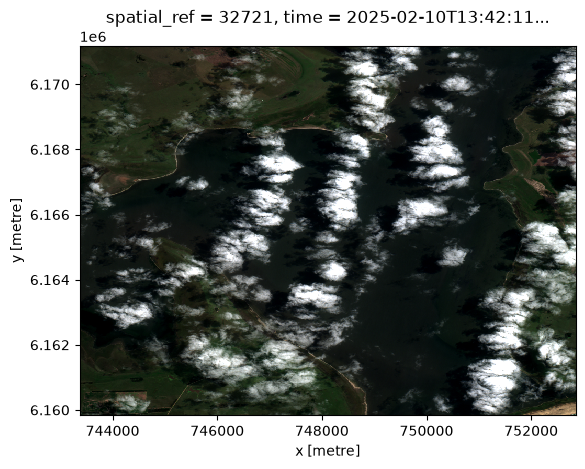

In [12]:
rgb = ds[["red", "green", "blue"]].isel(time=3).to_dataarray()
rgb.plot.imshow(robust=True)
plt.show()

In [ ]:
lon, lat = -54.27456, -34.65545
d = 0.03 #500 metros al rededor
bbox=[lon - d, lat - d, lon + d, lat + d]

items = catalog.search(
    collections=[SENTINEL_SURFACE_REFLECTION],
    datetime="2025-02-01/2025-02-20", # 4 * 6
    #query={"eo:cloud_cover": {"lt": 20}}, # solo retorna imagenes que tienen al menos 80 % sin nubes
    bbox=bbox
).item_collection()

ds2 = odc.stac.load(
    items,
    #bands=["green", "nir", "scl"],
    bands=["red", "green", "blue"],
    crs="EPSG:32721",
    resolution=10,
    bbox=bbox# ???
)

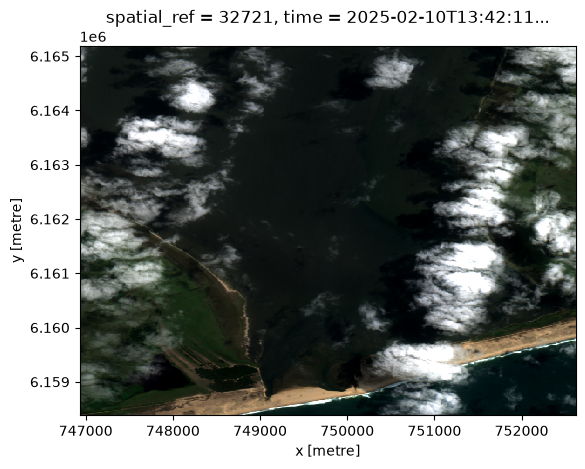

In [192]:
rgb = ds2[["red", "green", "blue"]].isel(time=3).to_dataarray()
rgb.plot.imshow(robust=True)
plt.show()

In [186]:

lon, lat = -54.26775, -34.58679
d = 0.05 #500 metros al rededor
bbox=[lon - d, lat - d, lon + d, lat + d]

items = catalog.search(
    collections=[SENTINEL_SURFACE_REFLECTION],
    datetime="2025-02-01/2025-02-20", # 4 * 6
    #query={"eo:cloud_cover": {"lt": 20}}, # solo retorna imagenes que tienen al menos 80 % sin nubes
    bbox=bbox
).item_collection()

ds3 = odc.stac.load(
    items,
    #bands=["green", "nir", "scl"],
    bands=["red", "green", "blue"],
    crs="EPSG:32721",
    resolution=10,
    bbox=bbox# ???
)

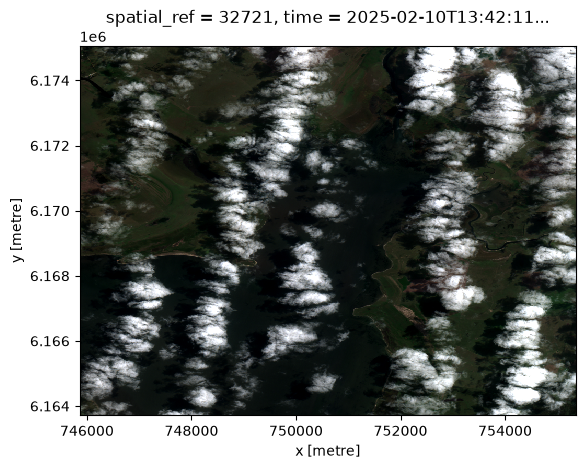

In [178]:
rgb = ds3[["red", "green", "blue"]].isel(time=3).to_dataarray()
rgb.plot.imshow(robust=True)
plt.show()

In [12]:
lon, lat = -54.26775, -34.58679
d = 0.05 #500 metros al rededor
bbox=[lon - d, lat - d, lon + d, lat + d]

items = catalog.search(
    collections=[SENTINEL_SURFACE_REFLECTION],
    datetime="2025-02-01/2025-02-20", # 4 * 6
    #query={"eo:cloud_cover": {"lt": 20}}, # solo retorna imagenes que tienen al menos 80 % sin nubes
    bbox=bbox
).item_collection()

ds3_rn = odc.stac.load(
    items,
    #bands=["green", "nir"],
    bands=["red", "rededge1"],
    crs="EPSG:32721",
    resolution=10,
    bbox=bbox# ???
)

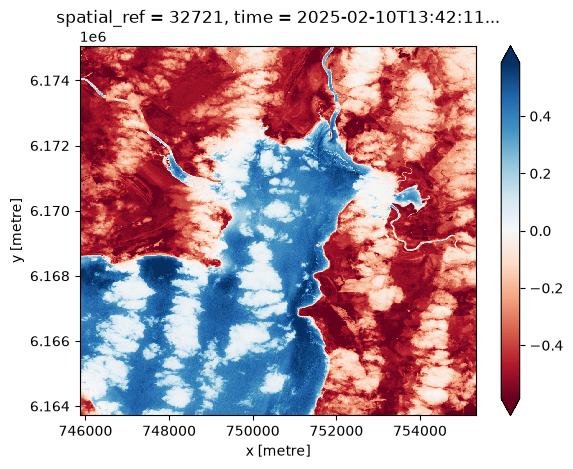

In [15]:
def calcular_ndwi(raster):
    eps = 1e-10
    green = raster["green"].astype("float32") # green
    nir = raster["nir"].astype("float32") # near infra red
    NDWI = (green - nir) / (green + nir + eps)
    return NDWI
    
def calcular_ndci(raster):
    eps = 1e-10
    b5 = raster["rededge1"].astype("float32")
    b4 = raster["red"].astype("float32")
    ndci = (b5 - b4) / (b5 + b4)
    return ndci
    
#NDWI = calcular_ndwi(ds3_rn)
#NDWI.isel(time=3).plot.imshow(cmap="RdBu", robust=True)
#plt.show()

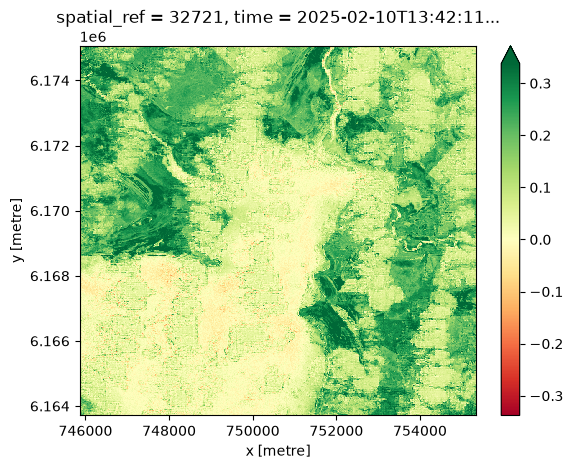

In [17]:
NDCI = calcular_ndci(ds3_rn)
NDCI.isel(time=3).plot.imshow(cmap="RdYlGn", robust=True)
plt.show()

In [209]:
((NDWI.isel(time=3) > 0.0).sum() * 10 * 10) / (1000.0**2)

<xarray.DataArray ()> Size: 8B
array(39.3298)
Coordinates:
    spatial_ref  int32 4B 32721
    time         datetime64[us] 8B 2025-02-10T13:42:11.135000
Attributes:
    nodata:   0

In [276]:
1000*1000

1000000

In [279]:
fila = df_gems[df_gems["nombre"] == "URY00008"].iloc[0]
print(fila.geometry.x, fila.geometry.y)

-55.2061 -34.4204


In [33]:
def registrar(sirve):
    global puntos_examinados_df
    fila = df_gems.iloc[i]
    fecha = _last_capture["fechas"][min(t, len(_last_capture["fechas"]) - 1)]

    nueva_fila = {
        "nombre": fila["nombre"],
        "geometry": fila.geometry,
        "Decision": sirve,
        "Fecha": fecha,
        "Width": D_DEFAULT,
        "Resolution": RESOLUTION_DEFAULT,
    }
    puntos_examinados_df = pd.concat(
        [puntos_examinados_df, pd.DataFrame([nueva_fila])], ignore_index=True
    )
    puntos_examinados_df.to_csv(CSV_PATH, index=False)

def bien():
    registrar("si")

def mal():
    registrar("no")

def dudoso():
    registrar("dudoso")

In [32]:
from typing import Literal

DATETIME_RANGE = "2025-02-01/2025-02-20"  # ventana corta, rapida para el caso comun
_VENTANA = pd.Timestamp(DATETIME_RANGE.split("/")[1]) - pd.Timestamp(DATETIME_RANGE.split("/")[0])
D_DEFAULT = 0.05
RESOLUTION_DEFAULT = 10

def capture_point(coords, d=D_DEFAULT, resolution=RESOLUTION_DEFAULT, capture_type: Literal["rgb", "ndwi"] = "rgb", datetime_range=DATETIME_RANGE):
    lon, lat = coords
    bbox = [lon - d, lat - d, lon + d, lat + d]

    items = catalog.search(
        collections=[SENTINEL_SURFACE_REFLECTION],
        datetime=datetime_range,
        bbox=bbox
    ).item_collection()

    # ordenamos de menos a mas nubosa, asi la fecha 0 es siempre la mejor opcion
    items = sorted(items, key=lambda it: it.properties.get("eo:cloud_cover", 100))
    fechas = [it.datetime.replace(tzinfo=None) for it in items]

    bands = ["green", "nir"] if capture_type == "ndwi" else ["red", "green", "blue"]

    ds = odc.stac.load(
        items,
        bands=bands,
        crs="EPSG:32721",
        resolution=resolution,
        bbox=bbox
    )

    return ds, bands, fechas

def plot_rgb(ds, station, bands, fecha):
    img = ds[bands].sel(time=fecha, method="nearest").to_dataarray()
    img.plot.imshow(robust=True)
    plt.title(station)
    plt.show()

def plot_ndwi(ndwi, station, fecha):
    p = ndwi.sel(time=fecha, method="nearest").plot.imshow(
        cmap="RdBu",
        robust=True,
        add_labels=False,          # drop the "x [metre]" / "y [metre]" labels
    )
    p.axes.set_title(station)
    p.axes.set_axis_off()          # remove ticks, numbers, and frame entirely
    plt.show()

In [22]:
_last_capture = {}

def ver(capture_type: Literal["ndwi", "rgb"] = "ndwi", recapture=False):
    global t
    fila = df_gems.iloc[i]
    coords = [fila.geometry.x, fila.geometry.y]
    name = fila["nombre"]

    need_new = recapture or _last_capture.get("capture_type") != capture_type or _last_capture.get("station") != name
    if need_new:
        ds, bands, fechas = capture_point(coords, capture_type=capture_type)
        fin = pd.Timestamp(DATETIME_RANGE.split("/")[1])
        _last_capture.clear()
        _last_capture.update(ds=ds, bands=bands, fechas=fechas, capture_type=capture_type,
                              station=name, coords=coords, fin=fin)
        t = 0

    ds, bands, fechas = _last_capture["ds"], _last_capture["bands"], _last_capture["fechas"]
    fecha = fechas[min(t, len(fechas) - 1)]
    print(f"{name} | fecha {t + 1}/{len(fechas)}: {fecha:%Y-%m-%d}")

    if capture_type == "ndwi":
        NDWI = calcular_ndwi(ds)
        plot_ndwi(NDWI, name, fecha)
    else:
        plot_rgb(ds, name, bands, fecha)

def _expandir_busqueda(capture_type):
    nuevo_inicio = _last_capture["fin"] + pd.Timedelta(days=1)
    nuevo_fin = nuevo_inicio + _VENTANA
    nuevo_rango = f"{nuevo_inicio:%Y-%m-%d}/{nuevo_fin:%Y-%m-%d}"

    ds_nuevo, _, fechas_nuevo = capture_point(_last_capture["coords"], capture_type=capture_type, datetime_range=nuevo_rango)

    if fechas_nuevo:
        _last_capture["ds"] = xr.concat([_last_capture["ds"], ds_nuevo], dim="time")
        _last_capture["fechas"] += fechas_nuevo
    _last_capture["fin"] = nuevo_fin

def siguiente_fecha(capture_type: Literal["ndwi", "rgb"] = "ndwi"):
    global t
    t += 1
    if t >= len(_last_capture["fechas"]):
        _expandir_busqueda(capture_type)  # no habia mas fechas cargadas, busca la siguiente ventana
    ver(capture_type=capture_type)

In [34]:
import os

i = 0
t = 0

CSV_PATH = "puntos_examinados.csv"

if os.path.exists(CSV_PATH):
    puntos_examinados_df = pd.read_csv(CSV_PATH)
else:
    puntos_examinados_df = pd.DataFrame(columns=["nombre", "Decision", "Fecha", "Width", "Resolution"])

In [35]:
def proximo():
    global i, t
    i += 1
    while df_gems.iloc[i]["nombre"] in set(puntos_examinados_df["nombre"]):
        i += 1
    t = 0
    print(i, df_gems.iloc[i]["nombre"])

URY00013 | fecha 1/8: 2025-02-01


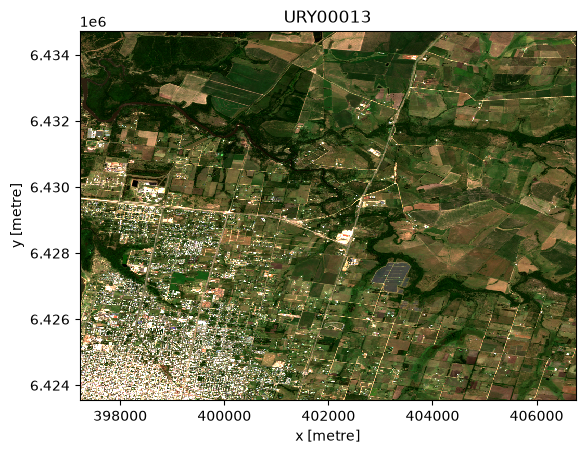

In [71]:
# Flujo de uso por punto:
#   ver()               -> muestra el NDWI del punto actual, con la fecha menos nubosa
#   siguiente_fecha()    -> si esta nublado, prueba la siguiente fecha (no vuelve a pedir datos)
#   bien() / mal() / dudoso() -> registra la decision del punto actual y pasa al siguiente

#ver("rgb")
#ver()



In [653]:
puntos_examinados_df

,nombre,Decision,Fecha,Width,Resolution,geometry
0,URY00006,si,2025-02-13 13:52:11.656000,0.05,10,POINT (-55.3727 -34.5071)
1,URY00006,dudoso,2025-02-13 13:52:11.656000,0.05,10,POINT (-55.3727 -34.5071)
2,URY00007,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2762 -34.391)
3,URY00008,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2061 -34.4204)
4,URY00009,dudoso,2025-02-13 13:51:57.401000,0.05,10,POINT (-55.2471 -34.3791)
...,...,...,...,...,...,...
194,URY00193,si,2025-02-01 14:01:58.144000,0.05,10,POINT (-57.261889 -33.248939)
195,URY00194,si,2025-02-01 14:01:58.144000,0.05,10,POINT (-57.413038 -32.905795)
196,URY00195,si,2025-02-01 14:01:58.144000,0.05,10,POINT (-58.234396 -33.519189)
197,URY00196,si,2025-02-01 14:01:58.144000,0.05,10,POINT (-56.85916 -33.262061)


In [1]:
def check():
    display(df_gems.iloc[[i]].explore(
        tiles="Esri.WorldImagery",
        marker_kwds={"radius": 8},
        color="red",
        zoom_start=16,          # higher = more zoomed in; 16–18 is close
    ))
    #display()

58 URY00064


In [828]:
bien()

In [795]:
dudoso()

In [813]:
mal()

In [2]:
check()

NameError: name 'df_gems' is not defined

In [829]:
#proximo()

IndexError: single positional indexer is out-of-bounds

In [831]:
puntos_examinados_df["Decision"].value_counts()

Decision
si        200
dudoso     33
no         25
Name: count, dtype: int64

[]

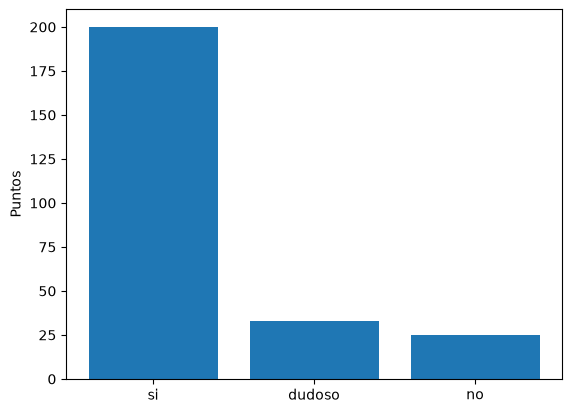

In [839]:
#puntos_examinados_df["Decision"].unique()
plt.bar(puntos_examinados_df["Decision"].unique(), puntos_examinados_df["Decision"].value_counts())
plt.ylabel("Puntos")
plt.plot()

In [840]:
puntos_examinados_df.iloc[0]

nombre                          URY00006
Decision                              si
Fecha         2025-02-13 13:52:11.656000
Width                               0.05
Resolution                            10
geometry       POINT (-55.3727 -34.5071)
Name: 0, dtype: object

AttributeError: 'DataFrame' object has no attribute 'explore'

In [842]:
type(df_gems)

geopandas.geodataframe.GeoDataFrame

In [843]:
type(puntos_examinados_df)

pandas.DataFrame

In [845]:
puntos = geo.GeoDataFrame(
    puntos_examinados_df,
    geometry="geometry",
    crs="EPSG:4326"
)

In [854]:
m = puntos.iloc[[0]].explore(tiles="Esri.WorldImagery", color="red", zoom_start=16, marker_kwds={"radius": 8})
m